# Paper-Style Simulation Reproduction

這份 notebook 會建立一組 synthetic spatial dataset，並比較 Ordinary Kriging、Machine Learning ensemble 與 weighted Fusion model。目標是用較小規模的實驗復現 combined Machine Learning + Kriging paper 的方法邏輯，方便放進期末報告。

## 1. 選擇 Simulation Case

先執行第一份 notebook 診斷真實 weather data，再把下方 `CASE_TYPE` 設成最接近的 behavior：`gaussian`、`non_stationary`、`trend` 或 `skewed_lognormal`。這樣報告會聚焦在和你的資料最相關的 case。

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

try:
    from pykrige.ok import OrdinaryKriging
except ImportError:
    OrdinaryKriging = None

sns.set_theme(style='whitegrid')
rng = np.random.default_rng(42)
CASE_TYPE = 'non_stationary'
N = 450
print({'case_type': CASE_TYPE, 'n': N})

{'case_type': 'non_stationary', 'n': 450}


## 2. 產生 Synthetic Spatial Data

synthetic field 代表未知的 true spatial process。不同公式會產生不同 behavior，例如 trend case 含有 large-scale coordinate trend，而 lognormal case 會在 exponentiation 後呈現 skewed distribution。

,x,y,z
0,0.773956,0.042351,0.507791
1,0.438878,0.884146,-0.521651
2,0.858598,0.709578,-0.085382
3,0.697368,0.173128,-1.202070
4,0.094177,0.091721,1.002208


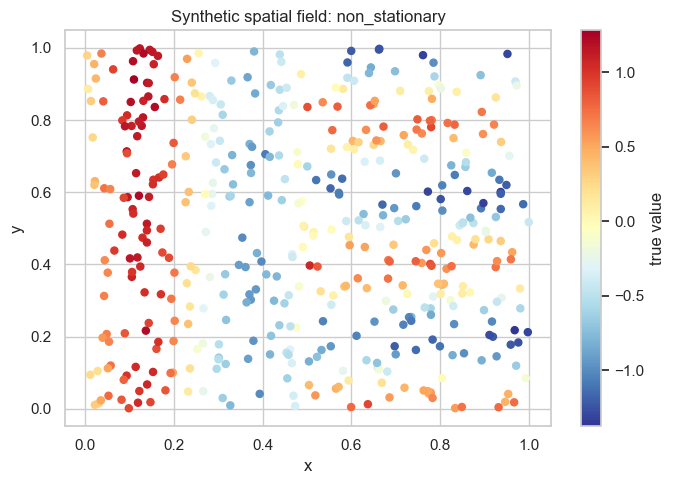

In [4]:
def generate_field(case_type, n):
    x = rng.uniform(0, 1, n)
    y = rng.uniform(0, 1, n)
    noise = rng.normal(0, 0.08, n)
    if case_type == 'gaussian':
        z = 2.0 + np.sin(2*np.pi*x) * 0.4 + np.cos(2*np.pi*y) * 0.3 + noise
    elif case_type == 'trend':
        z = 1.0 + 1.4*x - 0.8*y + 0.25*np.sin(4*np.pi*x*y) + noise
    elif case_type == 'skewed_lognormal':
        base = 0.4 + 0.7*np.sin(2*np.pi*x) + 0.5*np.cos(2*np.pi*y) + noise
        z = np.exp(base)
    else:
        left = np.sin(4*np.pi*x) + 0.2*y
        right = np.cos(5*np.pi*y) - 0.3*x
        z = np.where(x < 0.5, left, right) + noise
    return pd.DataFrame({'x': x, 'y': y, 'z': z})

sim = generate_field(CASE_TYPE, N)
display(sim.head())
plt.figure(figsize=(7, 5))
plt.scatter(sim['x'], sim['y'], c=sim['z'], cmap='RdYlBu_r', s=26)
plt.colorbar(label='true value')
plt.title(f'Synthetic spatial field: {CASE_TYPE}')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()

## 3. 訓練 Ordinary Kriging 與 Machine Learning Ensemble

這個 compact reproduction 會在 selected kernel 有 `PyKrige` 時使用 Ordinary Kriging。ML 部分使用簡化的 Super Learner-style average，整合 Random Forest、Extra Trees 與 Gradient Boosting，這些都是標準的 `scikit-learn` models。

In [5]:
def idw_predict(train_xy, train_y, target_xy, k=10):
    tree = cKDTree(train_xy)
    k = min(k, len(train_xy))
    distances, indexes = tree.query(target_xy, k=k)
    if k == 1:
        distances = distances[:, None]
        indexes = indexes[:, None]
    distances = np.maximum(distances, 1e-9)
    weights = 1 / distances**2
    weights = weights / weights.sum(axis=1, keepdims=True)
    pred = np.sum(train_y[indexes] * weights, axis=1)
    var = np.average((train_y[indexes] - pred[:, None])**2, axis=1, weights=weights)
    return pred, var

train, test = train_test_split(sim, test_size=0.35, random_state=42)
X_train = train[['x', 'y']].to_numpy()
y_train = train['z'].to_numpy()
X_test = test[['x', 'y']].to_numpy()
y_test = test['z'].to_numpy()

def kriging_predict(train_xy, train_y, target_xy):
    if OrdinaryKriging is None or len(train_xy) < 4:
        pred, var = idw_predict(train_xy, train_y, target_xy)
        return pred, var, 'IDW fallback'
    try:
        ok = OrdinaryKriging(
            train_xy[:, 0], train_xy[:, 1], train_y,
            variogram_model='spherical', verbose=False, enable_plotting=False
        )
        pred, var = ok.execute('points', target_xy[:, 0], target_xy[:, 1])
        return np.asarray(pred, dtype=float), np.asarray(var, dtype=float), 'OrdinaryKriging'
    except Exception as exc:
        print('PyKrige failed; using IDW fallback:', exc)
        pred, var = idw_predict(train_xy, train_y, target_xy)
        return pred, var, 'IDW fallback'

kr_pred, kr_var, kriging_method = kriging_predict(X_train, y_train, X_test)
print('spatial baseline:', kriging_method)
learners = [
    RandomForestRegressor(n_estimators=400, random_state=1, min_samples_leaf=2),
    ExtraTreesRegressor(n_estimators=400, random_state=2, min_samples_leaf=2),
    GradientBoostingRegressor(random_state=3),
]
ml_pred_parts = []
for model in learners:
    model.fit(X_train, y_train)
    ml_pred_parts.append(model.predict(X_test))
ml_pred = np.mean(ml_pred_parts, axis=0)

def metric_row(name, pred):
    return {'model': name, 'RMSE': mean_squared_error(y_test, pred)**0.5, 'MAE': mean_absolute_error(y_test, pred), 'R2': r2_score(y_test, pred)}

pd.DataFrame([metric_row(kriging_method, kr_pred), metric_row('ML ensemble', ml_pred)])

spatial baseline: OrdinaryKriging


,model,RMSE,MAE,R2
0,OrdinaryKriging,0.365743,0.312855,0.748119
1,ML ensemble,0.179664,0.138209,0.939220


## 4. 最佳化 Fusion Weight

paper 定義的 weight 會依賴 Kriging variance：`w(u) = (sigma_KR^2(u))^b`，其中 `b = b0 + b1 * Z_KR(u)`。這個 cell 會對 `b0` 與 `b1` 做 grid search，用來繪製類似 Figure 3(a) 的 loss surface，並找出 minimum。

{'best_b0': np.float64(0.1), 'best_b1': np.float64(-2.0), 'best_rmse': np.float64(0.1797966344549019)}


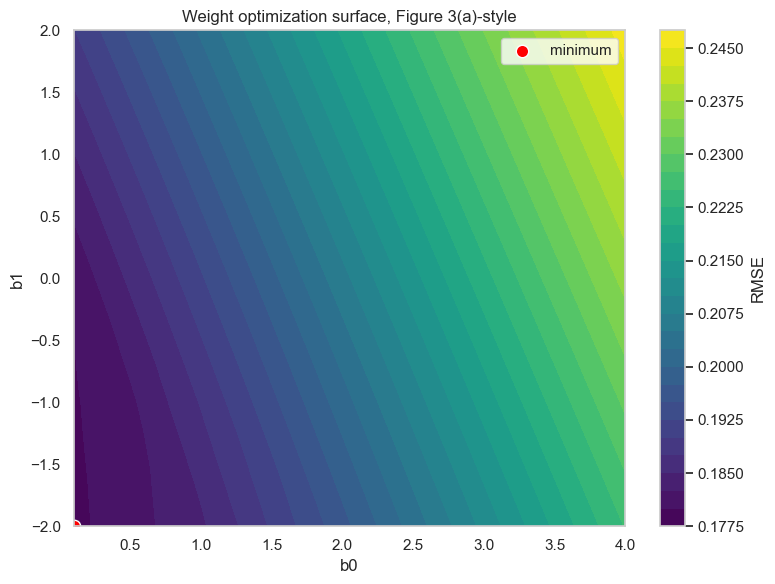

In [6]:
sigma = kr_var / max(float(np.max(kr_var)), 1e-9)
z_scaled = (kr_pred - kr_pred.min()) / max(float(kr_pred.max() - kr_pred.min()), 1e-9)

def fusion_from_params(b0, b1):
    b = np.clip(b0 + b1 * z_scaled, 0.01, 8.0)
    w = np.clip(sigma ** b, 0, 1)
    return w * ml_pred + (1 - w) * kr_pred, w

b0_grid = np.linspace(0.1, 4.0, 80)
b1_grid = np.linspace(-2.0, 2.0, 80)
loss = np.zeros((len(b1_grid), len(b0_grid)))
for i, b1 in enumerate(b1_grid):
    for j, b0 in enumerate(b0_grid):
        pred, _ = fusion_from_params(b0, b1)
        loss[i, j] = mean_squared_error(y_test, pred) ** 0.5

min_idx = np.unravel_index(np.argmin(loss), loss.shape)
best_b1 = b1_grid[min_idx[0]]
best_b0 = b0_grid[min_idx[1]]
best_pred, best_w = fusion_from_params(best_b0, best_b1)
print({'best_b0': best_b0, 'best_b1': best_b1, 'best_rmse': loss[min_idx]})

plt.figure(figsize=(8, 6))
contour = plt.contourf(b0_grid, b1_grid, loss, levels=30, cmap='viridis')
plt.colorbar(contour, label='RMSE')
plt.scatter([best_b0], [best_b1], c='red', s=80, edgecolor='white', label='minimum')
plt.xlabel('b0')
plt.ylabel('b1')
plt.title('Weight optimization surface, Figure 3(a)-style')
plt.legend()
plt.tight_layout()

## 5. 比較 Final Models

final comparison 會列出 RMSE、MAE 與 R²。這張表可以放進期末報告，用來說明 combined model 是否比 ordinary Kriging 有更好的預測表現。

,model,RMSE,MAE,R2
0,OrdinaryKriging,0.365743,0.312855,0.748119
1,ML ensemble,0.179664,0.138209,0.939220
2,Optimized fusion,0.179797,0.138357,0.939130


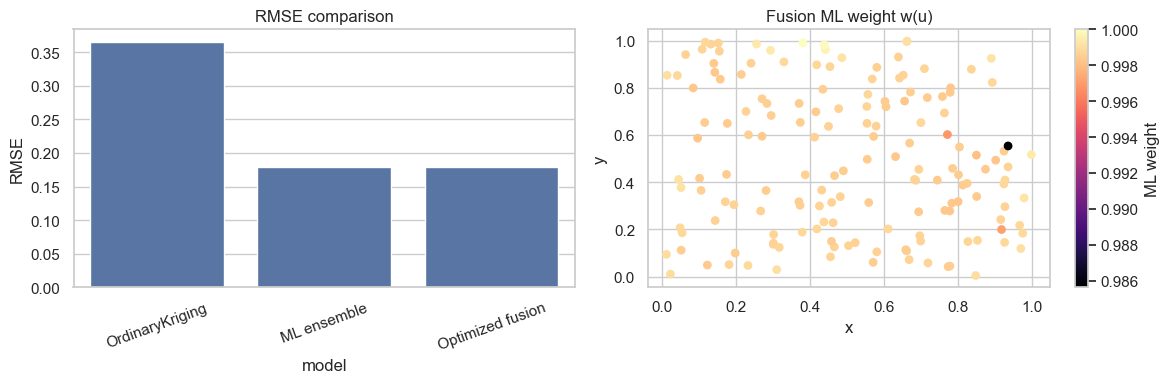

In [7]:
final_results = pd.DataFrame([
    metric_row(kriging_method, kr_pred),
    metric_row('ML ensemble', ml_pred),
    metric_row('Optimized fusion', best_pred),
])
display(final_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=final_results, x='model', y='RMSE', ax=axes[0])
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('RMSE comparison')
sc = axes[1].scatter(test['x'], test['y'], c=best_w, cmap='magma', s=28)
axes[1].set_title('Fusion ML weight w(u)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(sc, ax=axes[1], label='ML weight')
plt.tight_layout()